In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime
import warnings
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

# Teams

In [2]:
home= "Osasuna"
away= "Valencia"

In [3]:
df_home= pd.read_csv(f"../Data/{home}.csv")
df_home["Date"] = pd.to_datetime(df_home["Date"]) 
df_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
20,Osasuna,Las Palmas,2025-01-24,D,A,1,1,0,49,0,...,2.0,1.2,-1.6,-1.6,-2.0,0.17,2,0.7,0.09,-0.3
21,Osasuna,Real Sociedad,2025-02-02,W,H,2,1,1,38,0,...,0.4,0.8,1.3,1.3,1.6,0.06,0,1.1,0.38,0.1
22,Osasuna,Mallorca,2025-02-10,D,A,1,1,0,54,0,...,0.8,1.0,-0.4,-0.4,-0.8,0.09,0,0.8,0.02,-0.2
23,Osasuna,Real Madrid,2025-02-15,D,H,1,1,0,45,1,...,0.9,1.3,-0.4,-1.1,-0.9,0.12,0,1.1,0.22,0.1
24,Osasuna,Celta Vigo,2025-02-21,L,A,0,1,-1,54,0,...,0.6,1.0,-1.2,-1.2,-0.6,0.07,0,2.2,0.26,1.2


In [4]:
df_vs_home= pd.read_csv(f"../Data/vs {home}.csv")
df_vs_home["Date"] = pd.to_datetime(df_vs_home["Date"]) 
df_vs_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
20,Las Palmas,Osasuna,2025-01-24,D,H,1,1,0,51,0,...,0.5,0.7,0.2,0.2,-0.5,0.05,5,2.1,0.52,1.1
21,Real Sociedad,Osasuna,2025-02-02,L,A,1,2,-1,62,0,...,1.9,1.7,-1.0,-1.0,-0.9,0.16,0,0.9,0.23,-1.1
22,Mallorca,Osasuna,2025-02-10,D,H,1,1,0,46,1,...,0.2,0.7,-0.3,-0.5,-0.2,0.05,1,1.0,0.32,0.0
23,Real Madrid,Osasuna,2025-02-15,D,A,1,1,0,55,0,...,1.2,1.3,-0.4,-0.4,-0.2,0.08,1,1.0,0.20,0.0
24,Celta Vigo,Osasuna,2025-02-21,W,H,1,0,1,46,1,...,0.7,0.8,-0.8,-1.0,-0.7,0.09,0,0.1,0.12,0.1


In [5]:
df_away= pd.read_csv(f"../Data/{away}.csv")
df_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
20,Valencia,Barcelona,2025-01-26,L,A,1,7,-6,29,0,...,1.4,0.9,-0.5,-0.5,-0.4,0.22,1,5.5,0.50,-0.5
21,Valencia,Celta Vigo,2025-02-02,W,H,2,1,1,46,0,...,1.6,1.0,0.4,0.4,0.4,0.21,0,0.4,0.19,-0.6
22,Valencia,Leganés,2025-02-09,W,H,2,0,2,44,0,...,1.5,1.7,0.1,0.1,0.5,0.10,0,0.7,0.18,0.7
23,Valencia,Villarreal,2025-02-15,D,A,1,1,0,50,0,...,1.0,1.0,-0.1,-0.1,-1.0,0.09,0,0.7,0.17,-0.3
24,Valencia,Atlético Madrid,2025-02-22,L,H,0,3,-3,49,0,...,0.6,1.4,-0.8,-0.8,-0.6,0.05,1,2.1,0.70,-0.9


In [6]:
df_vs_away= pd.read_csv(f"../Data/vs {away}.csv")
df_vs_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_vs_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
20,Barcelona,Valencia,2025-01-26,W,H,7,1,6,71,0,...,3.8,1.8,1.6,1.6,1.2,0.21,0,0.8,0.47,-0.2
21,Celta Vigo,Valencia,2025-02-02,L,A,1,2,-1,54,0,...,0.4,0.5,0.6,0.6,0.6,0.13,0,1.8,0.41,-0.2
22,Leganés,Valencia,2025-02-09,L,A,0,2,-2,56,0,...,0.4,0.6,-0.5,-0.5,-0.4,0.04,1,2.0,0.52,0.0
23,Villarreal,Valencia,2025-02-15,D,H,1,1,0,50,0,...,1.2,1.2,-0.3,-0.3,-0.2,0.11,0,1.3,0.47,0.3
24,Atlético Madrid,Valencia,2025-02-22,W,A,3,0,3,51,0,...,0.9,1.8,1.7,1.7,2.1,0.11,1,0.1,0.04,0.1


In [7]:
print(list(df_away.columns))

['Team', 'Opp', 'Date', 'Result', 'H/A', 'GF', 'GA', 'GD', 'Poss', 'PKatt', 'G-PK', 'PK', 'PKm', 'Att (GK)', 'Thr', 'Pa Launch%', 'Pa AvgLen', 'Won', 'Lost', 'Won%', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 'PrgC', 'Last3rd Car', 'OppCr', 'Stp', 'Stp%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'GK Att', 'Launch%', 'AvgLen', 'Sh', 'G/Sh', 'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'PKcon', 'OG', 'Recov', '#OPA', 'AvgDist', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'PKdef', 'PKA', 'PKms', 'Missed PK%', 'PKAg', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassL

# Desc

# Features

## Offense

In [8]:
offense= ['G-PK', 'PK', 'PKm', 'Poss', 'PKatt', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 
          'PrgC', 'Last3rd Car', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'Sh', 'G/Sh', 
          'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 
          'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 
          'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 
          'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassLive Sc', 'PassDead Sc', 'TO Sc', 'Sh-Sh', 
          'Fld Sc', 'Def-Sc', 'Touches', 'Def Pen', 'Tch Def 3rd', 'Tch Mid 3rd', 'Tch Att 3rd', 'Att Pen', 'Live Tch', 'xG', 
          'npxG', 'xGD', 'npxGD', 'xAG', 'xA', 'G-xG', 'np:G-xG', 'A-xAG', 'npxG/Sh', 'FKAtt', 'GF']

In [9]:
df_home_off= df_home[offense]
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
20,1,0,0,49,0,20,10,50.0,10,50.0,...,1.9,1.9,2.0,1.2,-1.6,-1.6,-2.0,0.17,2,1
21,2,0,0,38,0,14,6,42.9,8,57.1,...,-1.4,-1.4,0.4,0.8,1.3,1.3,1.6,0.06,0,2
22,1,0,0,54,0,18,5,27.8,9,50.0,...,0.2,0.9,0.8,1.0,-0.4,-0.4,-0.8,0.09,0,1
23,0,1,0,45,1,15,9,60.0,5,33.3,...,0.1,-0.3,0.9,1.3,-0.4,-1.1,-0.9,0.12,0,1
24,0,0,0,54,0,21,6,28.6,8,38.1,...,-0.6,0.2,0.6,1.0,-1.2,-1.2,-0.6,0.07,0,0


In [10]:
df_vs_home_off= df_vs_home[offense]
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
20,1,0,0,51,0,10,3,30.0,7,70.0,...,-1.9,-1.9,0.5,0.7,0.2,0.2,-0.5,0.05,5,1
21,1,0,0,62,0,11,5,45.5,6,54.5,...,1.4,1.4,1.9,1.7,-1.0,-1.0,-0.9,0.16,0,1
22,0,1,0,46,1,8,2,25.0,5,62.5,...,-0.2,-0.9,0.2,0.7,-0.3,-0.5,-0.2,0.05,1,1
23,1,0,0,55,0,27,17,63.0,9,33.3,...,-0.1,0.3,1.2,1.3,-0.4,-0.4,-0.2,0.08,1,1
24,0,1,0,46,1,14,5,35.7,8,57.1,...,0.6,-0.2,0.7,0.8,-0.8,-1.0,-0.7,0.09,0,1


In [11]:
df_away_off= df_away[offense]
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
20,1,0,0,29,0,14,7,50.0,4,28.6,...,-2.9,-2.9,1.4,0.9,-0.5,-0.5,-0.4,0.22,1,1
21,2,0,0,46,0,26,8,30.8,13,50.0,...,1.2,1.2,1.6,1.0,0.4,0.4,0.4,0.21,0,2
22,2,0,0,44,0,19,3,15.8,11,57.9,...,1.3,1.3,1.5,1.7,0.1,0.1,0.5,0.10,0,2
23,1,0,0,50,0,15,10,66.7,5,33.3,...,-0.3,-0.3,1.0,1.0,-0.1,-0.1,-1.0,0.09,0,1
24,0,0,0,49,0,26,9,34.6,13,50.0,...,-0.4,-0.4,0.6,1.4,-0.8,-0.8,-0.6,0.05,1,0


In [12]:
df_vs_away_off= df_vs_away[offense]
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
20,6,0,0,71,0,28,15,53.6,8,28.6,...,2.9,2.9,3.8,1.8,1.6,1.6,1.2,0.21,0,7
21,1,0,0,54,0,20,5,25.0,12,60.0,...,-1.2,-1.2,0.4,0.5,0.6,0.6,0.6,0.13,0,1
22,0,0,0,56,0,25,8,32.0,16,64.0,...,-1.3,-1.3,0.4,0.6,-0.5,-0.5,-0.4,0.04,1,0
23,1,0,0,50,0,17,9,52.9,7,41.2,...,0.3,0.3,1.2,1.2,-0.3,-0.3,-0.2,0.11,0,1
24,3,0,0,51,0,13,5,38.5,8,61.5,...,0.4,0.4,0.9,1.8,1.7,1.7,2.1,0.11,1,3


## Defence

In [13]:
defence= ['OppCr', 'Stp', 'Stp%', 'PKcon', '#OPA', 'AvgDist', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'SoTA', 'Saves', 
          'Save%', 'Tkl', 'TklW', 'Tkl Def 3rd', 'Tkl Mid 3rd', 'Tkl Att 3rd', 'Tkl.2', 'Tkl Att', 'Tkl%', 'Lost Tkl', 
          'Ints', 'BlcSh', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err',  'PSxG', 'PSxG/SoT', 'PSxG+/-', 'GA']

In [14]:
df_home_def= df_home[defence]
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
20,11,0,0.0,0,1,14.7,0,NaN,1,0,...,3,8,3,15,26,0,0.7,0.09,-0.3,1
21,18,0,0.0,0,1,16.0,0,NaN,0,0,...,2,11,6,19,28,0,1.1,0.38,0.1,1
22,15,4,26.7,1,3,19.0,0,0.0,0,0,...,3,8,9,30,26,0,0.8,0.02,-0.2,1
23,6,1,16.7,0,5,23.8,0,NaN,0,0,...,5,7,5,17,18,2,1.1,0.22,0.1,1
24,7,1,14.3,1,7,27.7,0,0.0,0,0,...,2,6,6,19,12,0,2.2,0.26,1.2,1


In [15]:
df_vs_home_def= df_vs_home[defence]
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
20,13,0,0.0,0,1,16.3,0,NaN,0,0,...,6,6,8,22,24,0,2.1,0.52,1.1,1
21,12,1,8.3,0,0,9.2,0,NaN,0,0,...,4,9,7,26,21,1,0.9,0.23,-1.1,2
22,29,1,3.4,0,1,10.3,0,NaN,0,0,...,11,6,13,30,40,0,1.0,0.32,0.0,1
23,24,0,0.0,1,0,3.5,0,0.0,0,0,...,1,2,4,13,35,0,1.0,0.20,0.0,1
24,22,0,0.0,0,0,14.7,0,NaN,0,0,...,8,9,6,18,40,2,0.1,0.12,0.1,0


In [16]:
df_away_def= df_away[defence]
df_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,12,0,0.0,1,0,NaN,0,0.0,0,0,...,6,6,6,25,20,1,2.5,0.26,0.5,2
1,8,0,0.0,1,3,22.4,1,100.0,0,1,...,0,10,5,22,10,0,1.9,0.22,-1.1,3
2,18,2,11.1,0,2,17.0,0,NaN,0,0,...,5,2,10,33,29,0,0.8,0.21,-0.2,1
3,8,0,0.0,0,2,24.0,0,NaN,0,0,...,3,7,8,22,11,0,1.1,0.53,0.1,1
4,17,0,0.0,0,1,19.0,0,NaN,0,0,...,1,8,4,15,19,1,3.1,0.77,0.1,3


In [17]:
df_vs_away_def= df_vs_away[defence]
df_vs_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,10,0,0.0,0,0,2.0,0,NaN,0,0,...,2,7,4,18,13,1,0.9,0.91,-0.1,1
1,21,1,4.8,0,0,6.0,0,NaN,0,1,...,2,7,9,25,34,0,0.7,0.16,-0.3,1
2,11,2,18.2,0,3,18.1,0,NaN,0,0,...,1,3,10,24,27,0,0.0,NaN,0.0,0
3,32,0,0.0,0,0,6.5,0,NaN,0,1,...,6,7,2,16,50,0,2.0,0.39,1.0,1
4,11,1,9.1,0,0,3.0,0,NaN,0,0,...,1,13,5,17,18,0,0.1,0.07,0.1,0


## Combined

In [18]:
combined= ['Won', 'Lost', 'Won%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Recov']

In [19]:
df_home_cmb= df_home[combined]
df_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
20,15,12,55.6,8,0,0,17,12,43
21,19,20,48.7,3,0,0,10,8,48
22,20,17,54.1,4,0,0,11,6,38
23,23,8,74.2,3,0,0,16,7,35
24,18,14,56.3,0,0,0,13,11,38


In [20]:
df_vs_home_cmb= df_vs_home[combined]
df_vs_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
20,12,15,44.4,7,1,1,14,15,44
21,20,19,51.3,3,0,0,8,9,46
22,17,20,45.9,1,0,0,7,11,48
23,8,23,25.8,1,1,0,7,16,34
24,14,18,43.8,1,0,0,11,13,26


In [21]:
df_away_cmb= df_away[combined]
df_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
20,6,9,40.0,1,0,0,12,9,50
21,13,10,56.5,1,0,0,9,17,41
22,15,17,46.9,1,0,0,14,8,44
23,9,10,47.4,5,0,0,17,6,37
24,4,10,28.6,1,0,0,18,16,51


In [22]:
df_vs_away_cmb= df_vs_away[combined]
df_vs_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
20,9,6,60.0,0,0,0,10,12,48
21,10,13,43.5,2,0,0,17,8,37
22,17,15,53.1,1,0,0,9,12,41
23,10,9,52.6,0,0,0,6,17,44
24,10,4,71.4,3,0,0,16,16,44


## By Team

In [23]:
def create_lagged_features(df, target_cols, window= 4):
    """
    Creates lagged and rolling window features for a given dataset.
    
    Parameters:
    df (pd.DataFrame): The input dataframe containing game-by-game data.
    team_col (str): The column name representing the team.
    date_col (str): The column name representing the game date.
    target_cols (list): List of columns to create lagged and rolling features for.
    opponent_col (str, optional): Column representing the opponent team (if applicable).
    lags (list): List of lag periods to include.
    rolling_windows (list): List of rolling window sizes for moving averages and std dev.
    
    Returns:
    pd.DataFrame: Dataframe with additional lagged and rolling features.
    """
    df = df.copy()
    
    
    # Create lagged features for the given columns
    #for col in target_cols:
     #   for lag in range(1, window+1):
      #      df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    
    # Create rolling window features (mean & std)
    for col in target_cols:
        df[f'{col}_rolling_avg_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).mean()
        df[f'{col}_rolling_std_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).std()
    
    # Fill NA values (after shifting to avoid data leakage)
    df = df.fillna(0)
    
    return df


In [24]:
df_home_off= create_lagged_features(df_home_off, offense)
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
20,1,0,0,49,0,20,10,50.0,10,50.0,...,1.387779e-17,0.355903,-0.075,0.386221,0.065,0.023805,0.0,0.0,0.50,0.577350
21,2,0,0,38,0,14,6,42.9,8,57.1,...,-3.250000e-01,0.899537,-0.525,1.053170,0.095,0.054467,0.5,1.0,0.75,0.500000
22,1,0,0,54,0,18,5,27.8,9,50.0,...,-1.000000e-01,1.202775,-0.050,1.515476,0.085,0.056862,0.5,1.0,1.00,0.816497
23,0,1,0,45,1,15,9,60.0,5,33.3,...,-1.250000e-01,1.209339,-0.175,1.562850,0.095,0.051962,0.5,1.0,1.25,0.500000
24,0,0,0,54,0,21,6,28.6,8,38.1,...,-4.500000e-01,1.266228,-0.525,1.517399,0.110,0.046904,0.5,1.0,1.25,0.500000


In [25]:
df_vs_home_off= create_lagged_features(df_vs_home_off, offense)
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
20,1,0,0,51,0,10,3,30.0,7,70.0,...,-0.200,0.976388,-0.275,0.590903,0.1300,0.109848,0.25,0.500000,1.00,0.816497
21,1,0,0,62,0,11,5,45.5,6,54.5,...,-0.075,0.991211,-0.325,0.602080,0.1325,0.107199,1.50,2.380476,1.25,0.500000
22,0,1,0,46,1,8,2,25.0,5,62.5,...,-0.525,0.861684,-0.575,0.573730,0.1500,0.103602,1.50,2.380476,1.00,0.000000
23,1,0,0,55,0,27,17,63.0,9,33.3,...,-0.275,0.585235,-0.350,0.465475,0.0900,0.052281,1.75,2.217356,1.00,0.000000
24,0,1,0,46,1,14,5,35.7,8,57.1,...,-0.425,0.492443,-0.450,0.331662,0.0850,0.051962,1.75,2.217356,1.00,0.000000


In [26]:
df_away_def= create_lagged_features(df_away_def, defence)
df_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
20,12,0,0.0,0,3,16.6,0,0.0,0,0,...,0.75,0.957427,0.775,0.763217,0.140,0.116333,-0.475,0.531507,1.25,0.957427
21,8,1,12.5,0,3,19.7,0,0.0,0,0,...,1.00,0.816497,1.700,2.556039,0.195,0.214864,-0.550,0.500000,2.50,3.109126
22,6,0,0.0,0,0,8.0,0,0.0,0,0,...,0.75,0.957427,1.575,2.619637,0.195,0.214864,-0.425,0.359398,2.25,3.201562
23,11,0,0.0,0,3,16.0,0,0.0,0,0,...,0.50,0.577350,1.675,2.561738,0.225,0.197400,-0.075,0.602080,2.00,3.366502
24,2,0,0.0,0,4,25.4,0,0.0,0,0,...,0.50,0.577350,1.825,2.454078,0.260,0.160208,-0.175,0.596518,2.25,3.201562


In [27]:
df_vs_away_def= create_lagged_features(df_vs_away_def, defence)
df_vs_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
20,13,1,7.7,0,2,16.0,0,0.0,0,0,...,0.25,0.50000,1.075,0.613052,0.3700,0.095219,-0.175,0.457347,1.25,0.50000
21,7,1,14.3,0,0,9.3,0,0.0,0,0,...,0.25,0.50000,0.850,0.450925,0.4100,0.095219,-0.150,0.450925,1.00,0.00000
22,18,0,0.0,0,2,19.7,0,0.0,0,0,...,0.25,0.50000,0.950,0.624500,0.4050,0.094340,-0.300,0.270801,1.25,0.50000
23,10,1,10.0,0,1,10.4,0,0.0,0,0,...,0.25,0.50000,1.375,0.613052,0.4675,0.045000,-0.125,0.095743,1.50,0.57735
24,30,0,0.0,0,0,3.0,0,0.0,0,0,...,0.50,0.57735,1.475,0.537742,0.4675,0.045000,-0.025,0.236291,1.50,0.57735


In [28]:
df_away_off= create_lagged_features(df_away_off, offense)
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
20,1,0,0,29,0,14,7,50.0,4,28.6,...,-0.075,0.450000,-0.225,0.818026,0.1600,0.057155,0.00,0.0,1.25,0.50000
21,2,0,0,46,0,26,8,30.8,13,50.0,...,-0.275,0.403113,-0.425,0.704154,0.1900,0.045461,0.25,0.5,1.00,0.00000
22,2,0,0,44,0,19,3,15.8,11,57.9,...,-0.100,0.522813,-0.175,0.793200,0.1975,0.045735,0.25,0.5,1.25,0.50000
23,1,0,0,50,0,15,10,66.7,5,33.3,...,-0.150,0.479583,-0.175,0.793200,0.1900,0.060553,0.25,0.5,1.50,0.57735
24,0,0,0,49,0,26,9,34.6,13,50.0,...,-0.025,0.377492,-0.125,0.708872,0.1550,0.069522,0.25,0.5,1.50,0.57735


In [29]:
df_vs_away_off= create_lagged_features(df_vs_away_off, offense)
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
20,6,0,0,71,0,28,15,53.6,8,28.6,...,-0.025,0.556028,-0.250,0.500000,0.0825,0.033040,0.25,0.5,1.25,0.957427
21,1,0,0,54,0,20,5,25.0,12,60.0,...,0.325,1.004573,0.175,0.830161,0.1150,0.071414,0.00,0.0,2.50,3.109126
22,0,0,0,56,0,25,8,32.0,16,64.0,...,0.475,0.984463,0.450,0.704746,0.1175,0.071822,0.00,0.0,2.25,3.201562
23,1,0,0,50,0,17,9,52.9,7,41.2,...,0.225,1.096586,0.225,0.818026,0.1175,0.071822,0.25,0.5,2.00,3.366502
24,3,0,0,51,0,13,5,38.5,8,61.5,...,0.350,0.960902,0.300,0.739369,0.1225,0.069940,0.25,0.5,2.25,3.201562


In [30]:
df_home_def= create_lagged_features(df_home_def, defence)
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
20,11,0,0.0,0,1,14.7,0,0.0,1,0,...,0.50,0.57735,1.225,0.846069,0.2500,0.121929,0.225,0.718215,1.00,0.816497
21,18,0,0.0,0,1,16.0,0,0.0,0,0,...,0.50,0.57735,1.275,0.793200,0.2275,0.145230,0.025,0.727438,1.25,0.500000
22,15,4,26.7,1,3,19.0,0,0.0,0,0,...,0.25,0.50000,1.100,0.711805,0.2675,0.163376,0.100,0.711805,1.00,0.000000
23,6,1,16.7,0,5,23.8,0,0.0,0,0,...,0.00,0.00000,0.775,0.250000,0.1650,0.155885,-0.225,0.250000,1.00,0.000000
24,7,1,14.3,1,7,27.7,0,0.0,0,0,...,0.50,1.00000,0.925,0.206155,0.1775,0.158403,-0.075,0.206155,1.00,0.000000


In [31]:
df_vs_home_def= create_lagged_features(df_vs_home_def, defence)
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
20,13,0,0.0,0,1,16.3,0,0.0,0,0,...,0.75,0.957427,0.375,0.623832,0.173333,0.225019,-1.250000e-01,0.471699,0.50,0.577350
21,12,1,8.3,0,0,9.2,0,0.0,0,0,...,0.75,0.957427,0.900,0.983192,0.260000,0.252587,1.500000e-01,0.785281,0.75,0.500000
22,29,1,3.4,0,1,10.3,0,0.0,0,0,...,0.75,0.957427,0.800,0.948683,0.210000,0.226127,-2.000000e-01,0.983192,1.00,0.816497
23,24,0,0.0,1,0,3.5,0,0.0,0,0,...,0.25,0.500000,1.050,0.785281,0.287500,0.183916,-2.000000e-01,0.983192,1.25,0.500000
24,22,0,0.0,0,0,14.7,0,0.0,0,0,...,0.25,0.500000,1.250,0.568624,0.317500,0.144309,5.551115e-17,0.898146,1.25,0.500000


In [32]:
df_home_cmb.rename(columns= {col: f"h_{col}" for col in df_home_cmb.columns}, inplace= True)
df_home_cmb= create_lagged_features(df_home_cmb, df_home_cmb.columns)
df_home_cmb.tail()

,h_Won,h_Lost,h_Won%,h_CrdY,h_CrdR,h_2CrdY,h_Fls,h_Fld,h_Recov,h_Won_rolling_avg_4,...,h_CrdR_rolling_avg_4,h_CrdR_rolling_std_4,h_2CrdY_rolling_avg_4,h_2CrdY_rolling_std_4,h_Fls_rolling_avg_4,h_Fls_rolling_std_4,h_Fld_rolling_avg_4,h_Fld_rolling_std_4,h_Recov_rolling_avg_4,h_Recov_rolling_std_4
20,15,12,55.6,8,0,0,17,12,43,18.75,...,0.0,0.0,0.0,0.0,11.50,2.380476,10.50,3.696846,42.75,4.573474
21,19,20,48.7,3,0,0,10,8,48,19.75,...,0.0,0.0,0.0,0.0,12.50,3.696846,10.50,3.696846,43.50,4.203173
22,20,17,54.1,4,0,0,11,6,38,18.50,...,0.0,0.0,0.0,0.0,12.50,3.696846,9.50,3.696846,44.25,4.787136
23,23,8,74.2,3,0,0,16,7,35,20.00,...,0.0,0.0,0.0,0.0,11.75,3.593976,9.75,3.304038,41.75,4.787136
24,18,14,56.3,0,0,0,13,11,38,19.25,...,0.0,0.0,0.0,0.0,13.50,3.511885,8.25,2.629956,41.00,5.715476


In [33]:
df_vs_home_cmb.rename(columns= {col: f"vh_{col}" for col in df_vs_home_cmb.columns}, inplace= True)
df_vs_home_cmb= create_lagged_features(df_vs_home_cmb, df_vs_home_cmb.columns)
df_vs_home_cmb.tail()

,vh_Won,vh_Lost,vh_Won%,vh_CrdY,vh_CrdR,vh_2CrdY,vh_Fls,vh_Fld,vh_Recov,vh_Won_rolling_avg_4,...,vh_CrdR_rolling_avg_4,vh_CrdR_rolling_std_4,vh_2CrdY_rolling_avg_4,vh_2CrdY_rolling_std_4,vh_Fls_rolling_avg_4,vh_Fls_rolling_std_4,vh_Fld_rolling_avg_4,vh_Fld_rolling_std_4,vh_Recov_rolling_avg_4,vh_Recov_rolling_std_4
20,12,15,44.4,7,1,1,14,15,44,14.50,...,0.00,0.00000,0.00,0.0,11.75,2.500000,11.00,2.449490,40.75,1.258306
21,20,19,51.3,3,0,0,8,9,46,14.50,...,0.25,0.50000,0.25,0.5,12.00,2.708013,11.75,3.201562,42.00,1.414214
22,17,20,45.9,1,0,0,7,11,48,14.25,...,0.25,0.50000,0.25,0.5,10.75,3.201562,11.75,3.201562,43.25,2.217356
23,8,23,25.8,1,1,0,7,16,34,15.75,...,0.25,0.50000,0.25,0.5,10.50,3.511885,11.00,2.828427,44.75,2.986079
24,14,18,43.8,1,0,0,11,13,26,14.25,...,0.50,0.57735,0.25,0.5,9.00,3.366502,12.75,3.304038,43.00,6.218253


In [34]:
df_away_cmb.rename(columns= {col: f"va_{col}" for col in df_away_cmb.columns}, inplace= True)
df_away_cmb= create_lagged_features(df_away_cmb, df_away_cmb.columns)
df_away_cmb.tail()

,va_Won,va_Lost,va_Won%,va_CrdY,va_CrdR,va_2CrdY,va_Fls,va_Fld,va_Recov,va_Won_rolling_avg_4,...,va_CrdR_rolling_avg_4,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4
20,6,9,40.0,1,0,0,12,9,50,12.50,...,0.0,0.0,0.0,0.0,13.50,5.507571,11.50,3.415650,36.75,5.737305
21,13,10,56.5,1,0,0,9,17,41,11.00,...,0.0,0.0,0.0,0.0,11.50,3.415650,10.50,3.415650,38.25,8.421203
22,15,17,46.9,1,0,0,14,8,44,12.50,...,0.0,0.0,0.0,0.0,9.75,1.707825,13.00,3.651484,39.25,8.460693
23,9,10,47.4,5,0,0,17,6,37,14.25,...,0.0,0.0,0.0,0.0,11.25,2.217356,11.25,4.031129,42.75,5.852350
24,4,10,28.6,1,0,0,18,16,51,10.75,...,0.0,0.0,0.0,0.0,13.00,3.366502,10.00,4.830459,43.00,5.477226


In [35]:
df_vs_away_cmb.rename(columns= {col: f"a_{col}" for col in df_vs_away_cmb.columns}, inplace= True)
df_vs_away_cmb= create_lagged_features(df_vs_away_cmb, df_vs_away_cmb.columns)
df_vs_away_cmb.tail()

,a_Won,a_Lost,a_Won%,a_CrdY,a_CrdR,a_2CrdY,a_Fls,a_Fld,a_Recov,a_Won_rolling_avg_4,...,a_CrdR_rolling_avg_4,a_CrdR_rolling_std_4,a_2CrdY_rolling_avg_4,a_2CrdY_rolling_std_4,a_Fls_rolling_avg_4,a_Fls_rolling_std_4,a_Fld_rolling_avg_4,a_Fld_rolling_std_4,a_Recov_rolling_avg_4,a_Recov_rolling_std_4
20,9,6,60.0,0,0,0,10,12,48,21.0,...,0.25,0.5,0.0,0.0,13.00,3.162278,13.00,5.354126,44.75,2.753785
21,10,13,43.5,2,0,0,17,8,37,16.5,...,0.25,0.5,0.0,0.0,11.75,3.095696,11.25,3.593976,46.00,2.828427
22,17,15,53.1,1,0,0,9,12,41,15.5,...,0.00,0.0,0.0,0.0,13.75,3.304038,9.25,1.892969,43.25,4.856267
23,10,9,52.6,0,0,0,6,17,44,15.0,...,0.00,0.0,0.0,0.0,12.00,3.559026,10.25,2.061553,43.00,4.966555
24,10,4,71.4,3,0,0,16,16,44,11.5,...,0.00,0.0,0.0,0.0,10.50,4.654747,12.25,3.685557,42.50,4.654747


In [36]:
df_home_off.drop(columns=['GF'], inplace= True)
df_away_off.drop(columns=['GF'], inplace= True)
df_vs_home_off.drop(columns=['GF'], inplace= True)
df_vs_away_off.drop(columns=['GF'], inplace= True)

df_home_def.drop(columns=['GA'], inplace= True)
df_away_def.drop(columns=['GA'], inplace= True)
df_vs_home_def.drop(columns=['GA'], inplace= True)
df_vs_away_def.drop(columns=['GA'], inplace= True)

## Final DFs

In [37]:
df_home_frw= pd.concat([df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True), 
                        df_away_def[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
#df_home_frw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_frw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_frw["H/A"]= "H"
df_home_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4,H/A
0,0,0,0,54,0,21,6,28.6,8,38.1,...,0.57735,1.825,2.454078,0.26,0.160208,-0.175,0.596518,2.25,3.201562,H


In [38]:
df_home_gf= pd.concat([df_home_off[:-1], 
                       df_vs_home_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_home[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1
                       )
df_home_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,0,0,0,61,0,22,8,36.4,11,50.0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,H,1
1,1,0,0,46,0,12,4,33.3,8,66.7,...,0.0,0.0,11.000000,0.000000,12.000000,0.000000,36.00,0.000000,A,0
2,0,0,0,40,0,13,7,53.8,4,30.8,...,0.0,0.0,11.000000,0.000000,10.500000,2.121320,37.00,1.414214,H,3
3,2,0,0,50,0,16,9,56.3,7,43.8,...,0.0,0.0,10.333333,1.154701,11.333333,2.081666,40.00,5.291503,A,1
4,1,0,0,35,0,22,11,50.0,8,36.4,...,0.0,0.0,11.500000,2.516611,11.000000,1.825742,39.25,4.573474,H,2


In [39]:
df_home_bcw= pd.concat([df_home_def[-1:].reset_index(drop=True), 
                        df_away_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_home_bcw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_bcw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_bcw["H/A"]= "H"
df_home_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,7,1,14.3,1,7,27.7,0,0.0,0,0,...,0.0,0.0,0.0,13.0,3.366502,10.0,4.830459,43.0,5.477226,H


In [40]:
df_home_ga= pd.concat([df_home_def[:-1], 
                       df_vs_home_off[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_home[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_home_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,12,0,0.0,0,5,30.5,0,0.0,0,0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,H,0
1,20,2,10.0,0,0,7.0,0,0.0,0,0,...,0.0,0.0,11.000000,0.000000,12.000000,0.000000,36.00,0.000000,A,4
2,18,3,16.7,0,1,13.8,0,0.0,0,0,...,0.0,0.0,11.000000,0.000000,10.500000,2.121320,37.00,1.414214,H,2
3,6,0,0.0,0,6,26.1,0,0.0,0,0,...,0.0,0.0,10.333333,1.154701,11.333333,2.081666,40.00,5.291503,A,3
4,25,1,4.0,0,1,11.3,0,0.0,0,1,...,0.0,0.0,11.500000,2.516611,11.000000,1.825742,39.25,4.573474,H,1


In [41]:
df_away_frw= pd.concat([df_away_off[-1:].reset_index(drop=True), 
                        df_home_def[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_frw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_frw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_frw["H/A"]= "A"
df_away_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,0,0,0,49,0,26,9,34.6,13,50.0,...,0.0,0.0,0.0,13.0,3.366502,10.0,4.830459,43.0,5.477226,A


In [42]:
df_away_gf= pd.concat([df_away_off[:-1], 
                       df_vs_away_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_away[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,1,0,0,37,0,17,6,35.3,9,52.9,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,A,1
1,1,0,0,51,0,12,4,33.3,7,58.3,...,0.0,0.0,11.000000,0.000000,12.000000,0.000000,36.00,0.000000,A,0
2,0,0,0,50,0,17,8,47.1,6,35.3,...,0.0,0.0,11.000000,0.000000,10.500000,2.121320,37.00,1.414214,H,1
3,1,0,0,58,0,19,9,47.4,8,42.1,...,0.0,0.0,10.333333,1.154701,11.333333,2.081666,40.00,5.291503,A,0
4,0,0,0,47,0,18,7,38.9,10,55.6,...,0.0,0.0,11.500000,2.516611,11.000000,1.825742,39.25,4.573474,H,2


In [43]:
df_away_bcw= pd.concat([df_away_def[-1:].reset_index(drop=True), 
                        df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_bcw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_bcw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_bcw["H/A"]= "H"
df_away_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,2,0,0.0,0,4,25.4,0,0.0,0,0,...,0.0,0.0,0.0,13.0,3.366502,10.0,4.830459,43.0,5.477226,H


In [44]:
df_away_ga= pd.concat([df_away_def[:-1], 
                       df_vs_away_off[:-1],
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_away[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,12,0,0.0,1,0,0.0,0,0.0,0,0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,A,3
1,8,0,0.0,1,3,22.4,1,100.0,0,1,...,0.0,0.0,11.000000,0.000000,12.000000,0.000000,36.00,0.000000,A,1
2,18,2,11.1,0,2,17.0,0,0.0,0,0,...,0.0,0.0,11.000000,0.000000,10.500000,2.121320,37.00,1.414214,H,1
3,8,0,0.0,0,2,24.0,0,0.0,0,0,...,0.0,0.0,10.333333,1.154701,11.333333,2.081666,40.00,5.291503,A,3
4,17,0,0.0,0,1,19.0,0,0.0,0,0,...,0.0,0.0,11.500000,2.516611,11.000000,1.825742,39.25,4.573474,H,0


In [45]:
df_home_gf = df_home_gf.fillna(0)

In [46]:
df_home_ga = df_home_ga.fillna(0)

In [47]:
df_away_ga = df_away_ga.fillna(0)

In [48]:
df_away_gf = df_away_gf.fillna(0)

# Categories

In [49]:
# Define bins for football goals classification
bins = [-1, 0, 1, 2, 3, float('inf')]  # -1 to include 0 as a bin
labels = [0, 1, 2, 3, 4]  # Assigning numeric class labels

# Apply binning
df_home_gf['GFC'] = pd.cut(df_home_gf['GF'], bins=bins, labels=labels)
df_away_gf['GFC'] = pd.cut(df_away_gf['GF'], bins=bins, labels=labels)
df_home_ga['GAC'] = pd.cut(df_home_ga['GA'], bins=bins, labels=labels)
df_away_ga['GAC'] = pd.cut(df_away_ga['GA'], bins=bins, labels=labels)

In [50]:
df_home_gf.drop(columns=['GF'], inplace= True)
df_away_gf.drop(columns=['GF'], inplace= True)

df_home_ga.drop(columns=['GA'], inplace= True)
df_away_ga.drop(columns=['GA'], inplace= True)


# Models

## Classification

### Model Home

In [51]:
target = "GFC"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [52]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [53]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

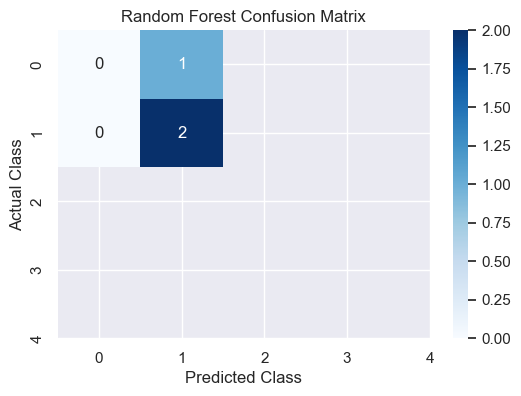

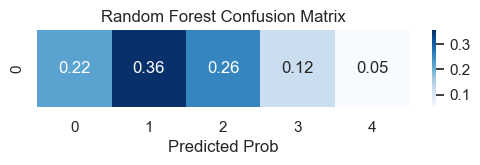

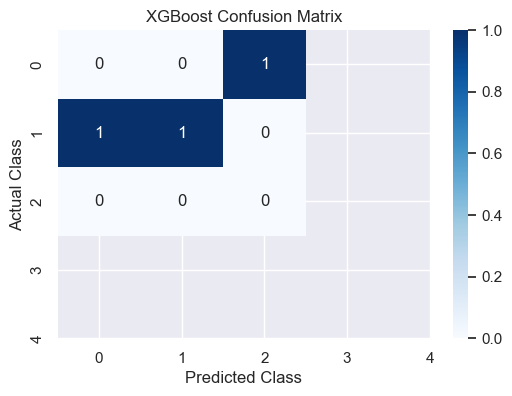

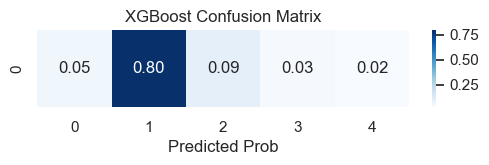

In [54]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Home

In [55]:
target = "GAC"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [56]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

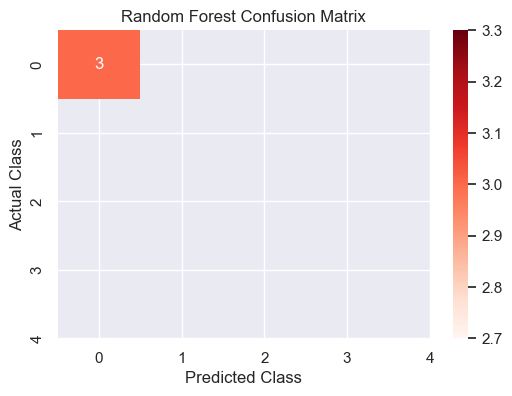

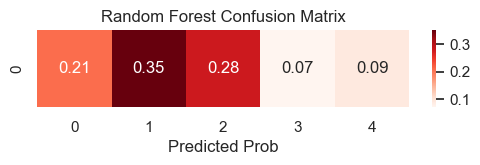

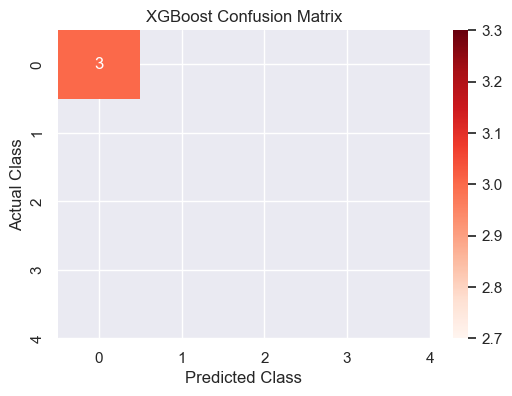

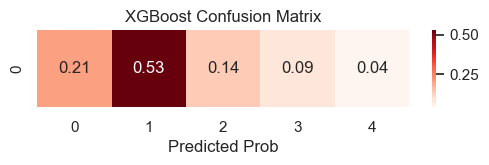

In [58]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model Away

In [59]:
target = "GFC"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [60]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [61]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

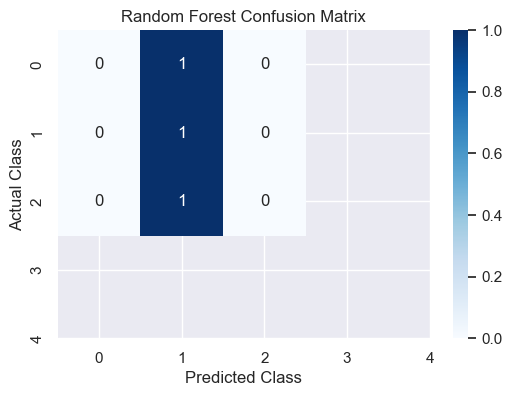

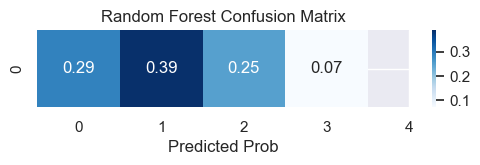

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3], got [0 1 2 4]

In [62]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Away

In [63]:
target = "GAC"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [64]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [65]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

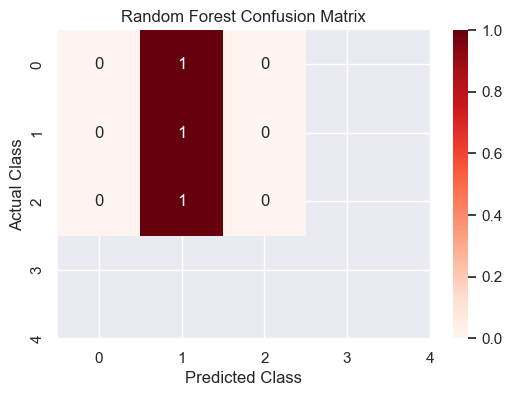

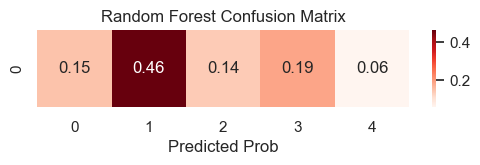

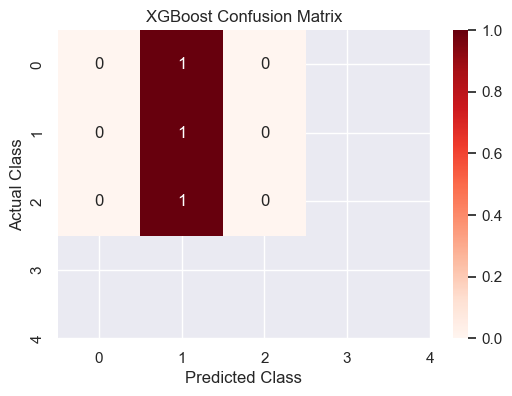

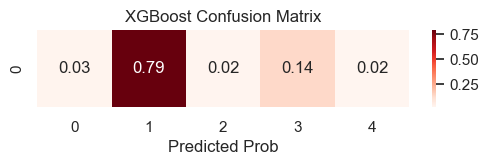

In [66]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

## Regression

### Model Home

In [67]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


KeyError: "['Tm_PTS'] not found in axis"

In [68]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [69]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

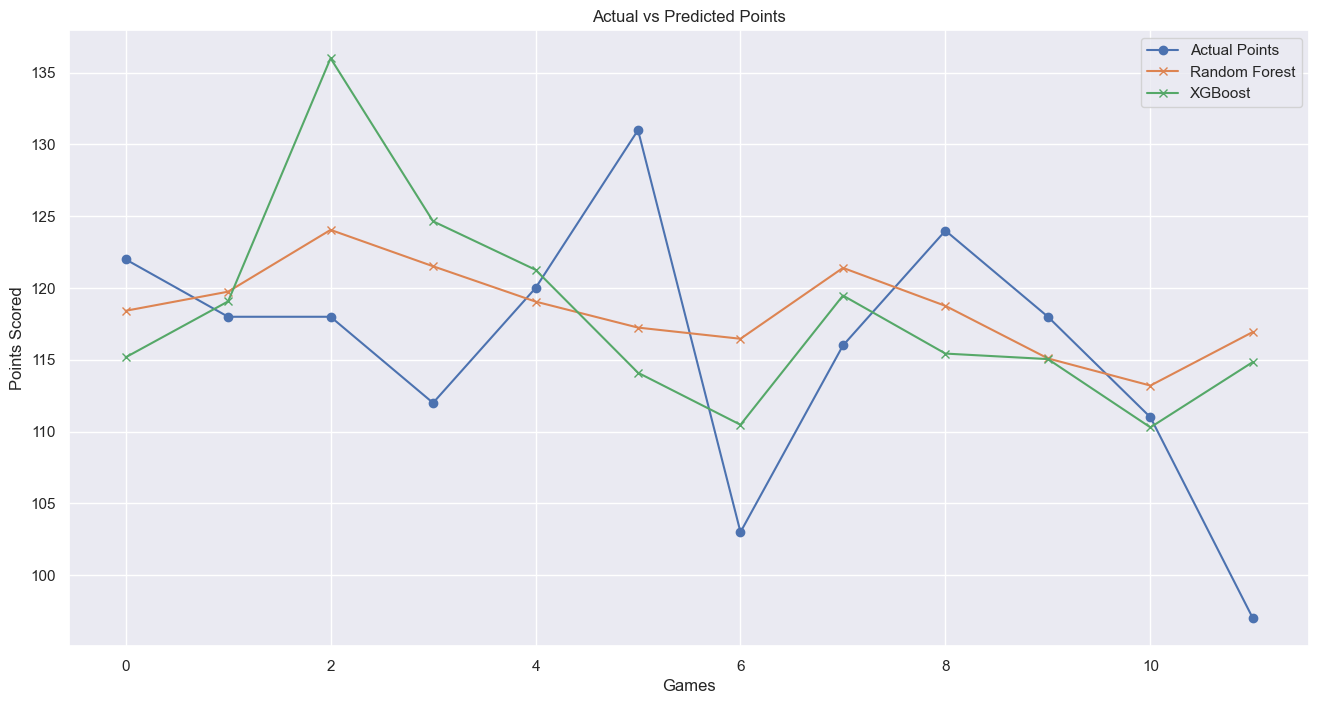

In [85]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

# Split into training and testing sets
train_size = int(len(X) * 0.8)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
# Train and evaluate each model
results = {}
plt.figure(figsize=(16,8))
plt.plot(y_test.values, label='Actual Points', marker='o')
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    plt.plot(y_pred, label=name, marker='x')
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred[0]}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T
plt.legend()
plt.title("Actual vs Predicted Points")
plt.xlabel("Games")
plt.ylabel("Points Scored")
plt.show()

In [80]:
results_df

,MAE,RMSE,PRED
Random Forest,7.063876,9.047376,117.443289
XGBoost,8.145854,10.362132,118.500099


### Model vs Home

In [48]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [49]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [50]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 13.425
RMSE: 14.329


In [52]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6818
[LightGBM] [Info] Number of data points in the train set: 52, number of used features: 405
[LightGBM] [Info] Start training from score 108.211538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [53]:
results_df

,MAE,RMSE,PRED
Random Forest,13.041667,13.840622,[108.75]
XGBoost,13.151134,15.03493,[113.32865]
LightGBM,16.852781,18.445559,[102.71760442340414]
Linear Regression,24.528301,25.202121,[84.73789959470245]


### Model Away

In [54]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [55]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 12.708
RMSE: 14.490


In [59]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6654
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 121.941176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [60]:
results_df

,MAE,RMSE,PRED
Random Forest,14.915,16.475376,[120.74]
XGBoost,12.521159,13.834184,[121.489395]
LightGBM,13.837515,17.031631,[126.221659266553]
Linear Regression,14.006226,16.370987,[137.60611314295068]


### Model vs Away

In [61]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [62]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [63]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 10.350
RMSE: 11.309


In [65]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6692
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 110.666667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [66]:
results_df

,MAE,RMSE,PRED
Random Forest,11.596667,12.906048,[108.99]
XGBoost,15.120514,16.820382,[102.5551]
LightGBM,9.838286,11.897321,[109.56588285586935]
Linear Regression,14.973625,19.146221,[86.82162740707135]
